In [1]:
import pandas as pd
import os
import random
import chardet
import requests
import json
import numpy as np
from urllib3.util.retry import Retry
import openai
from requests.adapters import HTTPAdapter
import os
import pickle
import matplotlib.pyplot as plt
# from utils.read_group_danmu import read_group_danmu

In [2]:
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-FullMovies\Emotion_scores\scores_allMovies_resample.pkl', 'rb') as f:
    scores_dict = pickle.load(f)
# del scores_dict['BV1zW411d7Rb']
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-FullMovies\Emotion_scores\times_allMovies_resample.pkl', 'rb') as f:
    time_dict= pickle.load(f)
# del time_dict['BV1zW411d7Rb']

print(len(scores_dict.keys()))
print(len(time_dict.keys()))

102
102


In [3]:
scores_all = np.zeros((0,6))
n_samples = []

scores_key = list(scores_dict.keys())
count = 0
for key in scores_key:
    print(scores_dict[key].shape)
    scores_all = np.concatenate((scores_all, scores_dict[key]), 0)
    n_samples.append(scores_dict[key].shape[0])
    count += 1
print(scores_all.shape)
n_samples_cum = np.concatenate((np.array([0]), np.cumsum(n_samples)))
print(n_samples_cum[-5:])

(4565, 6)
(3699, 6)
(4218, 6)
(1158, 6)
(3955, 6)
(3907, 6)
(4714, 6)
(3192, 6)
(2984, 6)
(3800, 6)
(3051, 6)
(3007, 6)
(4277, 6)
(5197, 6)
(3371, 6)
(3058, 6)
(3692, 6)
(3824, 6)
(3642, 6)
(3513, 6)
(6846, 6)
(2616, 6)
(2717, 6)
(3223, 6)
(3500, 6)
(4148, 6)
(3174, 6)
(3960, 6)
(3516, 6)
(3088, 6)
(4303, 6)
(2692, 6)
(4010, 6)
(2179, 6)
(2700, 6)
(4200, 6)
(3530, 6)
(3611, 6)
(3210, 6)
(4031, 6)
(3293, 6)
(4606, 6)
(5233, 6)
(3487, 6)
(4200, 6)
(3405, 6)
(4484, 6)
(3562, 6)
(3987, 6)
(4766, 6)
(3337, 6)
(2703, 6)
(2995, 6)
(2522, 6)
(4044, 6)
(3547, 6)
(3019, 6)
(2789, 6)
(1396, 6)
(3753, 6)
(3557, 6)
(4445, 6)
(5073, 6)
(3361, 6)
(3299, 6)
(3914, 6)
(2651, 6)
(2634, 6)
(3734, 6)
(3296, 6)
(5312, 6)
(4252, 6)
(2729, 6)
(2721, 6)
(3117, 6)
(2910, 6)
(4223, 6)
(2703, 6)
(3214, 6)
(3854, 6)
(3990, 6)
(3631, 6)
(3372, 6)
(2874, 6)
(3032, 6)
(2207, 6)
(3129, 6)
(2081, 6)
(2788, 6)
(2601, 6)
(4910, 6)
(3071, 6)
(1895, 6)
(4002, 6)
(4031, 6)
(3191, 6)
(2957, 6)
(3355, 6)
(2830, 6)
(3452, 6)


Explained variance ratio: [0.49378133 0.19681466 0.16693501 0.08574263 0.03698317 0.01974321]


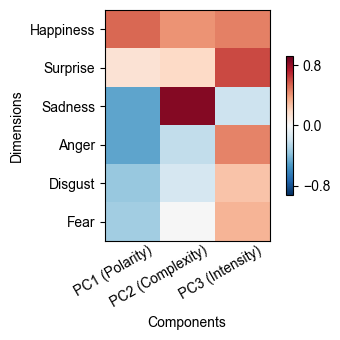

In [4]:
from sklearn.decomposition import PCA
import matplotlib
emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(preds_all)

pca = PCA(n_components=6)

X_pca = pca.fit_transform(scores_all)

print("Explained variance ratio:", pca.explained_variance_ratio_)

pca.components_[[3,4],:] = -pca.components_[[3,4],:]

matplotlib.rcParams['font.size'] = 10
matplotlib.rcParams['font.family'] = 'Arial'
fig, ax = plt.subplots(figsize=(4,3.5))
cax = ax.imshow(pca.components_.transpose()[:,:3],cmap='RdBu_r')
ax.set_aspect(0.7)
plt.xticks(np.arange(0.4,3.4,1),['PC1 (Polarity)', 'PC2 (Complexity)', 'PC3 (Intensity)'], rotation=30, ha='right')
plt.gca().tick_params(axis='x', pad=2)
plt.tick_params(axis='x', length=0)
plt.yticks(np.arange(6), emos)
plt.xlabel('Components')
plt.ylabel('Dimensions')
cbar = plt.colorbar(cax, shrink=0.6)
cbar.set_ticks([-0.8, 0.0, 0.8])
# max_lim = np.maximum(np.nanmax(pca.components_), -np.nanmin(pca.components_))
cax.set_clim([-0.921, 0.921])
# print(max_lim)
plt.tight_layout()
# plt.savefig('figures/pca_scores_danmu_all_PC3.svg', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
pca.components_.transpose()[:,2]

array([ 0.46514079,  0.60761063, -0.18949919,  0.45981599,  0.26599222,
        0.31042039])

In [6]:
from copy import deepcopy
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_gpt3_5_turbo.pkl', 'rb') as f:
    preds = pickle.load(f)

In [7]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Circle, FancyArrowPatch
from scipy.ndimage import gaussian_filter
from sklearn.decomposition import PCA
from sklearn.neighbors import KernelDensity

def _scott_bandwidth(X2):
    X2 = np.asarray(X2, float); n, d = X2.shape
    s = X2.std(axis=0, ddof=1).mean()
    return s * n ** (-1.0 / (d + 4))

def _hdr_thresholds(dens_grid, levels=(0.5, 0.8, 0.95), cell_area=1.0):
    f = dens_grid.ravel()
    idx = np.argsort(f)[::-1]
    mass = np.cumsum(f[idx]) * cell_area
    total = mass[-1]
    thr = []
    for a in levels:
        k = np.searchsorted(mass, a*total)
        k = min(max(k, 0), len(f)-1)
        thr.append(float(f[idx[k]]))
    return sorted(thr)

def _kde_on_grid(X2, xs, ys, bandwidth):
    XX, YY = np.meshgrid(xs, ys)
    grid = np.c_[XX.ravel(), YY.ravel()]
    kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth)
    kde.fit(X2)
    logd = kde.score_samples(grid)
    dens = np.exp(logd).reshape(XX.shape)
    return XX, YY, dens

def _global_assign_and_transition(scores_all, centers6, n_samples_cum, eps=1e-6):
    X = np.asarray(scores_all, float)
    dif = X[:, None, :] - centers6[None, :, :]
    d2 = np.sum(dif*dif, axis=2)
    labels = d2.argmin(axis=1).astype(int)  # 0..5

    K = 6
    C = np.zeros((K, K), float)
    M = len(n_samples_cum) - 1
    for m in range(M):
        s, e = int(n_samples_cum[m]), int(n_samples_cum[m+1])
        if e - s <= 1: continue
        seg = labels[s:e]
        for a, b in zip(seg[:-1], seg[1:]):
            C[a, b] += 1.0
    P = C + eps
    P = P / P.sum(axis=1, keepdims=True)
    pi = (P.sum(axis=0) + eps)
    pi = pi / pi.sum()
    return labels, P, pi

def fit_six_emotion_anchors(
    scores_all, topk_frac=0.20, eps=1e-6
):

    X = np.asarray(scores_all, float)
    N, D = X.shape
    assert D == 6

    sums = X.sum(axis=1, keepdims=True) + eps
    purity = X / sums  
    centers = np.zeros((6, D), float)
    covs = np.zeros((6, D, D), float)
    counts = np.zeros(6, int)

    for k in range(6):
        mask = (X.argmax(axis=1) == k)
        Xk = X[mask]
        # if len(Xk) < min_n:
        #     idx = np.argsort(purity[:, k])[::-1]
        #     take = max(min_n, int(topk_frac * N))
        #     Xk = X[idx[:take]]

        m = len(Xk)
        # print(int(topk_frac * m))
        kk = int(topk_frac * m)
        idx2 = np.argsort(Xk[:, k])[::-1][:kk]
        Xk2 = Xk[idx2]

        centers[k] = Xk2.mean(axis=0)
        C = np.cov(Xk2, rowvar=False)
        C = 0.5*(C + C.T) + 1e-9*np.eye(D)
        covs[k] = C
        counts[k] = len(Xk2)
    return centers, covs, counts

EMO_NAMES  = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]
EMO_COLORS = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']

In [8]:
centers6, covs6, counts = fit_six_emotion_anchors(
    scores_all,        # (N, 6)
    # purity_tau=1.0,   
    topk_frac=0.50 
    # min_n=500         
)
print("anchors per emotion:", counts)

anchors per emotion: [112913  37849  12221  13095    787   1218]


Explained variance ratio: [0.49378133 0.19681466 0.16693501 0.08574263 0.03698317 0.01974321]
Cumulative explained variance: 1.0


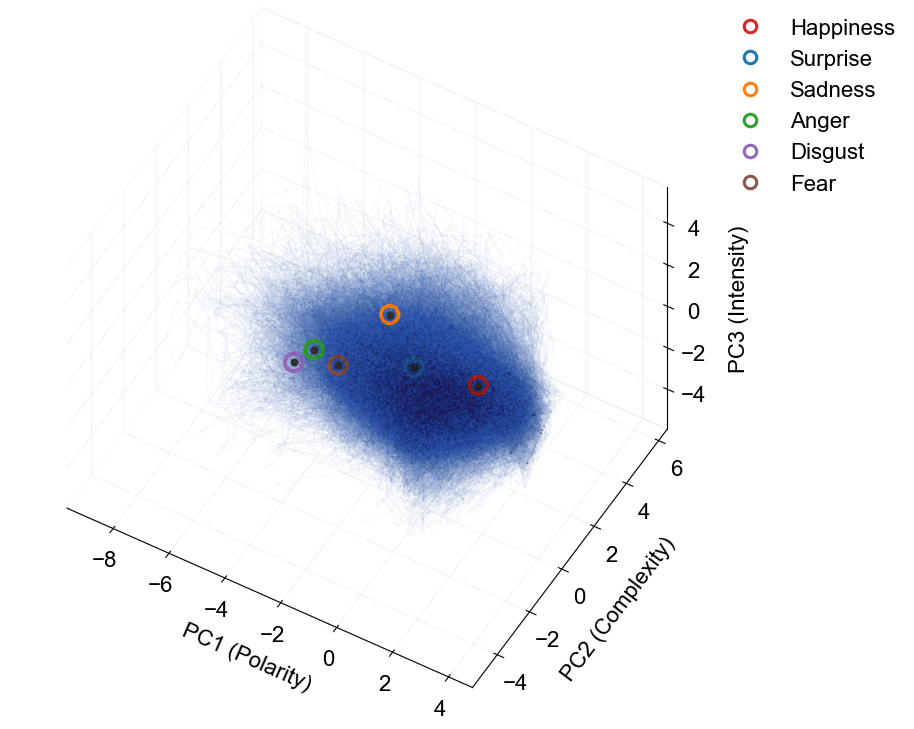

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from matplotlib.lines import Line2D

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 16
random_state = 0
traj_alpha = 0.045

rng = np.random.default_rng(random_state)

# ============================================================
# 1) PCA(3) on pooled data
# ============================================================
# pca = PCA(n_components=3, svd_solver="full", random_state=random_state)
X3 = pca.fit_transform(scores_all)
X3 = X3[:,:3]
C3 = pca.transform(centers6)
C3 = C3[:,:3]

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative explained variance:", pca.explained_variance_ratio_.sum())

# ============================================================
# 2) Prepare 3D trajectories for each movie
# ============================================================
traj_lines = []
for i in range(102):
    seg = X3[n_samples_cum[i]: n_samples_cum[i + 1]]
    traj_lines.append(seg)

# ============================================================
# 3) Axis limits
# ============================================================
pad = 0.03

xmin, xmax = X3[:, 0].min(), X3[:, 0].max()
ymin, ymax = X3[:, 1].min(), X3[:, 1].max()
zmin, zmax = X3[:, 2].min(), X3[:, 2].max()

dx = xmax - xmin
dy = ymax - ymin
dz = zmax - zmin

xmin -= pad * dx
xmax += pad * dx
ymin -= pad * dy
ymax += pad * dy
zmin -= pad * dz
zmax += pad * dz

# ============================================================
# 4) Plot 3D points and trajectories
# ============================================================
EMO_COLORS = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']
EMO_COLORS_WHITE_BG = EMO_COLORS

out_path_fig = 'figures/emotion_dynamic_space3D_points_traj_view1.jpg'

fig = plt.figure(figsize=(9, 8), facecolor="white")
ax = fig.add_subplot(111, projection="3d")
ax.set_facecolor("white")

idx = np.arange(0,len(X3),5)

# 所有 emotion states 的点
ax.scatter(
    X3[idx, 0], X3[idx, 1], X3[idx, 2],
    s=2.5,
    c="#333333",
    alpha=0.01,
    linewidths=0,
    depthshade=False,
    rasterized=True,
    zorder=0
)

ax.scatter(
    X3[idx, 0], X3[idx, 1], X3[idx, 2],
    s=1.0,
    c="#1A1A1A",
    alpha=0.03,
    linewidths=0,
    depthshade=False,
    rasterized=True,
    zorder=1
)

# 每部电影的 3D trajectory
for seg in traj_lines:
    ax.plot(
        seg[:, 0], seg[:, 1], seg[:, 2],
        lw=0.8,
        alpha=traj_alpha,
        color="#2E5CB8",
        zorder=2
    )

# ============================================================
# 5) Emotion centers in 3D
# ============================================================
center_mass = X3.mean(axis=0)

for k, (cx, cy, cz) in enumerate(C3):
    # 3D 里不用 Circle patch，直接用空心 scatter 作为 ring
    ax.scatter(
        [cx], [cy], [cz],
        s=160,
        facecolors="none",
        edgecolors=EMO_COLORS_WHITE_BG[k],
        linewidths=2.8,
        depthshade=False,
        zorder=4
    )

    ax.scatter(
        [cx], [cy], [cz],
        s=22,
        color="#333333",
        depthshade=False,
        zorder=5
    )

    # 标签位置略微偏移，避免覆盖中心点
    lx = cx - 0.035 * dx
    ly = cy + 0.035 * dy
    lz = cz + 0.035 * dz

    # ax.text(
    #     lx, ly, lz,
    #     EMO_NAMES[k],
    #     color=EMO_COLORS_WHITE_BG[k],
    #     fontsize=13,
    #     weight="bold",
    #     zorder=6
    # )
    
legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markerfacecolor='white',
        markeredgecolor=EMO_COLORS_WHITE_BG[k],
        markeredgewidth=2.2,
        markersize=9,
        label=EMO_NAMES[k]
    )
    for k in range(len(EMO_NAMES))
]

ax.legend(
    handles=legend_handles,
    loc='upper left',
    bbox_to_anchor=(1.02, 1.00),
    frameon=False,
    fontsize=16,
    borderaxespad=0.0
)

# ============================================================
# 6) Axes settings
# ============================================================
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_zlim(zmin, zmax)

ax.set_xlabel("PC1 (Polarity)")
ax.set_ylabel("PC2 (Complexity)")
ax.set_zlabel("PC3 (Intensity)")

ax.xaxis.labelpad = 10   # 增大x轴标签与轴的距离
ax.yaxis.labelpad = 10
ax.zaxis.labelpad = 10

# 让三个轴比例更接近真实 PCA 空间
try:
    ax.set_box_aspect((dx, dy, dz))
except Exception:
    pass

# 可调视角
# ax.view_init(elev=22, azim=-60)
# ax.set_proj_type("ortho")
ax.view_init(elev=50, azim=-60)
ax.set_proj_type("ortho")

# 简化 3D pane 背景
ax.xaxis.pane.set_facecolor((1, 1, 1, 0))
ax.yaxis.pane.set_facecolor((1, 1, 1, 0))
ax.zaxis.pane.set_facecolor((1, 1, 1, 0))

ax.grid(True)

# 3D 网格线调淡，避免喧宾夺主
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"].update({
        "color": (0.65, 0.65, 0.65, 0.22),
        "linewidth": 0.45,
        "linestyle": "-"
    })

plt.tight_layout()
plt.savefig(out_path_fig, dpi=600, bbox_inches="tight")
plt.show()

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from sklearn.decomposition import PCA
from skimage.measure import marching_cubes

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


# ============================================================
# 0. Basic settings
# ============================================================

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 14

random_state = 0
rng = np.random.default_rng(random_state)

EMO_NAMES = [
    "Happiness",
    "Surprise",
    "Sadness",
    "Anger",
    "Disgust",
    "Fear"
]

EMO_COLORS = [
    '#d62728',
    '#1f77b4',
    '#ff7f0e',
    '#2ca02c',
    '#9467bd',
    '#8c564b'
]

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

grid_res = 400

# Match the 2D KDE logic
# bandwidth = None
bandwidth = 0.174
bandwidth_scale = 1.0

# Same HDR probability masses as the final 2D plot
hdr_levels = (0.25, 0.50, 0.75)

# PCA-space padding
pad = 0.01

# Output
out_dir = "figures"
os.makedirs(out_dir, exist_ok=True)


# ============================================================
# 1. Scott bandwidth
#    Same definition as your 2D version
# ============================================================

def _scott_bandwidth_nd(X):

    X = np.asarray(X, dtype=float)

    n, d = X.shape

    # Same logic as:
    # s = X2.std(axis=0, ddof=1).mean()
    # bandwidth = s * n ** (-1 / (d + 4))

    s = X.std(
        axis=0,
        ddof=1
    ).mean()

    bw = s * n ** (
        -1.0 / (d + 4)
    )

    return bw


# ============================================================
# 2. HDR thresholds
# ============================================================
#
# Find density thresholds enclosing a given fraction
# of total probability mass.
#
# 25% HDR = highest-density region containing 25%
#           of probability mass.
#
# ============================================================

def _hdr_thresholds_3d(
    density,
    levels=(0.25, 0.50, 0.75),
    voxel_volume=1.0
):

    f = np.asarray(
        density,
        dtype=float
    ).ravel()

    # Sort density from high to low
    idx = np.argsort(f)[::-1]

    sorted_density = f[idx]

    # Integrated probability mass
    cumulative_mass = (
        np.cumsum(sorted_density)
        * voxel_volume
    )

    total_mass = cumulative_mass[-1]

    thresholds = {}

    for level in levels:

        target_mass = level * total_mass

        k = np.searchsorted(
            cumulative_mass,
            target_mass
        )

        k = min(
            max(k, 0),
            len(sorted_density) - 1
        )

        thresholds[level] = float(
            sorted_density[k]
        )

    return thresholds


# ============================================================
# 3. Refit PCA with 3 components
# ============================================================

pca3 = PCA(
    n_components=3,
    svd_solver="full",
    random_state=random_state
)

X3 = pca3.fit_transform(
    scores_all
)

C3 = pca3.transform(
    centers6
)

print(
    "Explained variance ratio:",
    pca3.explained_variance_ratio_
)

print(
    "Cumulative explained variance:",
    pca3.explained_variance_ratio_.sum()
)

print(
    "\nEmotion centers in PC space:"
)

for name, c in zip(
    EMO_NAMES,
    C3
):
    print(
        f"{name:10s}: "
        f"PC1={c[0]: .3f}, "
        f"PC2={c[1]: .3f}, "
        f"PC3={c[2]: .3f}"
    )


# ============================================================
# 4. Define common 3D grid
# ============================================================

xmin0, xmax0 = (
    X3[:, 0].min(),
    X3[:, 0].max()
)

ymin0, ymax0 = (
    X3[:, 1].min(),
    X3[:, 1].max()
)

zmin0, zmax0 = (
    X3[:, 2].min(),
    X3[:, 2].max()
)

dx0 = xmax0 - xmin0
dy0 = ymax0 - ymin0
dz0 = zmax0 - zmin0


xmin = xmin0 - pad * dx0
xmax = xmax0 + pad * dx0

ymin = ymin0 - pad * dy0
ymax = ymax0 + pad * dy0

zmin = zmin0 - pad * dz0
zmax = zmax0 + pad * dz0


# ============================================================
# 5. 3D histogram
# ============================================================
#
# This provides samples on a regular 72 x 72 x 72 grid.
#
# Gaussian convolution below approximates Gaussian KDE,
# while avoiding direct KDE evaluation at ~370k grid points.
#
# ============================================================

H, edges = np.histogramdd(
    X3,
    bins=(
        grid_res,
        grid_res,
        grid_res
    ),
    range=[
        [xmin, xmax],
        [ymin, ymax],
        [zmin, zmax]
    ]
)


# ============================================================
# 6. Grid centers and voxel geometry
# ============================================================

x_centers = 0.5 * (
    edges[0][:-1]
    + edges[0][1:]
)

y_centers = 0.5 * (
    edges[1][:-1]
    + edges[1][1:]
)

z_centers = 0.5 * (
    edges[2][:-1]
    + edges[2][1:]
)


sx = (
    x_centers[1]
    - x_centers[0]
)

sy = (
    y_centers[1]
    - y_centers[0]
)

sz = (
    z_centers[1]
    - z_centers[0]
)


voxel_size = np.array([
    sx,
    sy,
    sz
])

voxel_volume = (
    sx * sy * sz
)

print(
    "\nVoxel size:",
    voxel_size
)

print(
    "Voxel volume:",
    voxel_volume
)


# ============================================================
# 7. Scott bandwidth
#    Same isotropic Gaussian bandwidth logic as 2D
# ============================================================

if bandwidth is None:

    bandwidth = (
        _scott_bandwidth_nd(X3)
        * float(bandwidth_scale)
    )


print(
    "\n3D Scott bandwidth:",
    bandwidth
)


# Same scalar bandwidth in PCA space.
#
# Because PC1/PC2/PC3 grid spacing can differ,
# convert the SAME physical bandwidth into
# axis-specific numbers of voxels.

sigma_bins = (
    bandwidth
    / voxel_size
)

print(
    "Gaussian sigma in voxel units:",
    sigma_bins
)


# ============================================================
# 8. Gaussian KDE approximation
# ============================================================

density = gaussian_filter(
    H.astype(float),
    sigma=sigma_bins,
    mode="constant"
)


# Convert from smoothed counts to probability density
#
# Integral density * dV = 1

density /= (
    density.sum()
    * voxel_volume
)


print(
    "\nIntegrated density:",
    density.sum()
    * voxel_volume
)


# ============================================================
# 9. HDR thresholds
# ============================================================

hdr_thresholds = _hdr_thresholds_3d(
    density,
    levels=hdr_levels,
    voxel_volume=voxel_volume
)


print(
    "\nHDR thresholds:"
)

for level in hdr_levels:

    print(
        f"{level:.0%} HDR: "
        f"{hdr_thresholds[level]:.6g}"
    )


# ============================================================
# 10. Extract 3D isosurfaces using marching cubes
# ============================================================

surface_meshes = {}


for level in hdr_levels:

    threshold = (
        hdr_thresholds[level]
    )

    verts, faces, normals, values = (
        marching_cubes(
            density,
            level=threshold,
            spacing=(
                sx,
                sy,
                sz
            )
        )
    )

    # marching_cubes coordinates start at 0.
    # Shift them into the actual PCA coordinate system.

    verts[:, 0] += x_centers[0]
    verts[:, 1] += y_centers[0]
    verts[:, 2] += z_centers[0]

    surface_meshes[level] = (
        verts,
        faces
    )

    print(
        f"{level:.0%} HDR surface: "
        f"{len(verts)} vertices, "
        f"{len(faces)} faces"
    )


# ============================================================
# 11. Find global density peak
# ============================================================
#
# Step 1:
# identify the grid voxel with maximum KDE density
#
# Step 2:
# find the observed emotion state nearest to its center
#
# This matches the logic used in the manuscript Methods.
# ============================================================

peak_idx = np.unravel_index(
    np.argmax(density),
    density.shape
)


peak_grid_xyz = np.array([
    x_centers[
        peak_idx[0]
    ],
    y_centers[
        peak_idx[1]
    ],
    z_centers[
        peak_idx[2]
    ]
])


# Nearest observed data point

dist2 = np.sum(
    (
        X3
        - peak_grid_xyz[None, :]
    ) ** 2,
    axis=1
)

peak_data_idx = np.argmin(
    dist2
)

peak_xyz = X3[
    peak_data_idx
]


print(
    "\nPeak voxel index:",
    peak_idx
)

print(
    "Peak voxel center:",
    peak_grid_xyz
)

print(
    "Nearest observed emotion state:",
    peak_xyz
)

print(
    "Distance from peak voxel center:",
    np.sqrt(
        dist2[peak_data_idx]
    )
)


# ============================================================
# 12. Optional:
#     emotion profile at the 3D density peak
# ============================================================

peak_emotion_scores = (
    scores_all[
        peak_data_idx
    ]
)

print(
    "\nEmotion profile at 3D peak:"
)

for name, value in zip(
    EMO_NAMES,
    peak_emotion_scores
):

    print(
        f"{name:10s}: "
        f"{value:.3f}"
    )


# ============================================================
# 13. Plotting parameters
# ============================================================

# Neutral color avoids suggesting that the HDRs
# themselves correspond to a particular emotion.

SURFACE_COLOR = "#6F6F6F"


# Inner = denser = more visible
surface_alpha = {
    0.25: 0.22,
    0.50: 0.12,
    0.75: 0.06
}


peak_color = "#3B9AB2"


# Use actual displayed axis ranges for box aspect

dx = xmax - xmin
dy = ymax - ymin
dz = zmax - zmin


Explained variance ratio: [0.49378133 0.19681466 0.16693501]
Cumulative explained variance: 0.857530995911784

Emotion centers in PC space:
Happiness : PC1= 1.577, PC2= 0.505, PC3= 0.439
Surprise  : PC1=-0.331, PC2=-0.175, PC3= 0.885
Sadness   : PC1=-2.932, PC2= 2.832, PC3=-1.229
Anger     : PC1=-3.379, PC2=-1.083, PC3= 0.854
Disgust   : PC1=-3.811, PC2=-1.594, PC3= 0.508
Fear      : PC1=-2.536, PC2=-1.052, PC3= 0.568

Voxel size: [0.03489673 0.02901205 0.02810665]
Voxel volume: 2.8455888026673264e-05

3D Scott bandwidth: 0.174
Gaussian sigma in voxel units: [4.98614045 5.99750861 6.19070648]

Integrated density: 0.9999999999999978

HDR thresholds:
25% HDR: 0.0287427
50% HDR: 0.0132586
75% HDR: 0.00422821
25% HDR surface: 33670 vertices, 67336 faces
50% HDR surface: 69722 vertices, 139440 faces
75% HDR surface: 139396 vertices, 278788 faces

Peak voxel index: (320, 175, 207)
Peak voxel center: [ 1.80935428 -0.21179995  0.12099451]
Nearest observed emotion state: [ 1.8045618  -0.2052912

In [51]:
peak_xyz

array([ 1.8045618 , -0.20529125,  0.12385206])

In [10]:
# ============================================================
# Display limits for 3D visualization
# ============================================================

# Remove extreme tails only for visualization
q_low = 0.005
q_high = 0.995

view_xmin, view_xmax = np.quantile(
    X3[:, 0], [q_low, q_high]
)

view_ymin, view_ymax = np.quantile(
    X3[:, 1], [q_low, q_high]
)

view_zmin, view_zmax = np.quantile(
    X3[:, 2], [q_low, q_high]
)

# Small padding
pad_ratio = 0.03

def add_padding(vmin, vmax, ratio=0.03):
    d = vmax - vmin
    return vmin - ratio * d, vmax + ratio * d

view_xmin, view_xmax = add_padding(
    view_xmin, view_xmax, pad_ratio
)

view_ymin, view_ymax = add_padding(
    view_ymin, view_ymax, pad_ratio
)

view_zmin, view_zmax = add_padding(
    view_zmin, view_zmax, pad_ratio
)

print(
    "Display limits:",
    (view_xmin, view_xmax),
    (view_ymin, view_ymax),
    (view_zmin, view_zmax)
)

view_dx = view_xmax - view_xmin
view_dy = view_ymax - view_ymin
view_dz = view_zmax - view_zmin

Display limits: (-5.4394346553390855, 3.937511927002209) (-2.5983266613258182, 4.176515893390368) (-3.347294337830139, 2.8853058301107994)


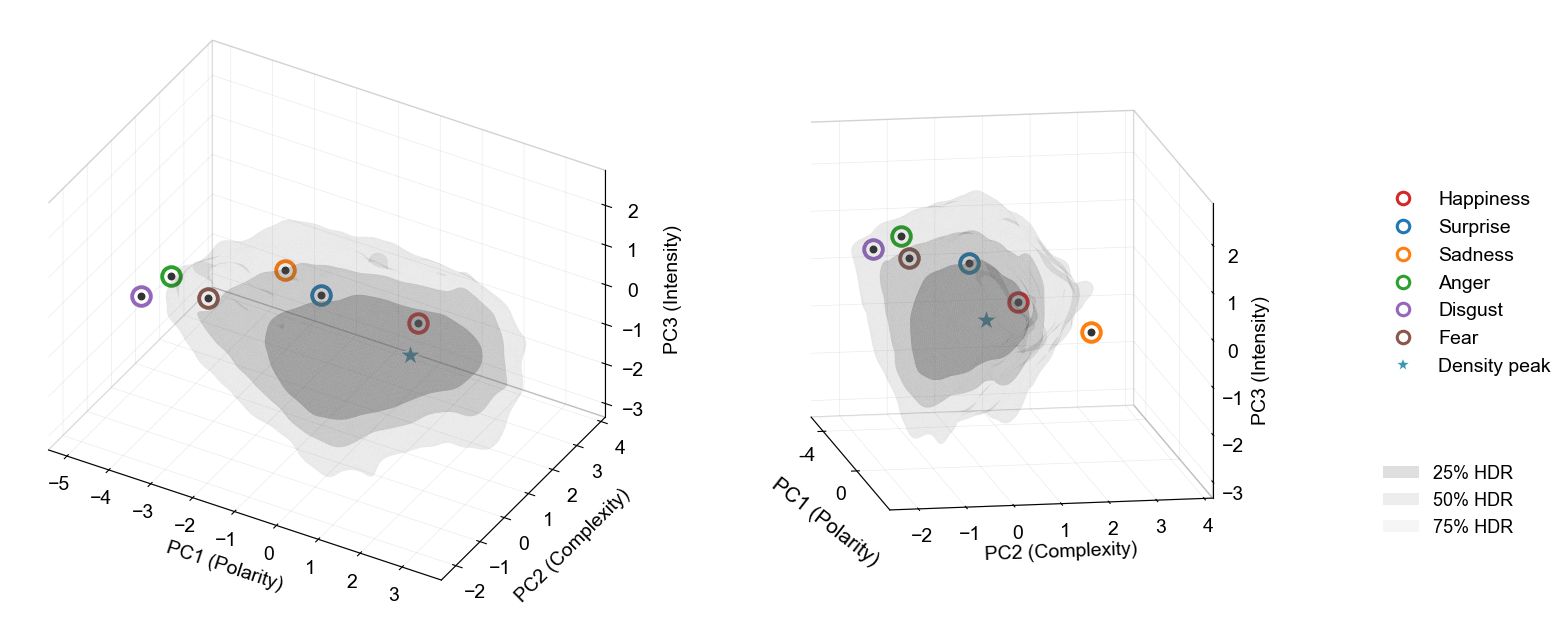

In [11]:
# ============================================================
# 14. Function to draw one viewing angle
# ============================================================

def plot_density_view(
    ax,
    elev,
    azim,
    show_title=None,
    manual_x_label=False,
    x_label_xy=None,
    sparse_xticks=False
):

    ax.set_facecolor("white")

    # --------------------------------------------------------
    # A. HDR isosurfaces
    # --------------------------------------------------------

    for level in [
        0.75,
        0.50,
        0.25
    ]:

        verts, faces = surface_meshes[level]

        mesh = Poly3DCollection(
            verts[faces],
            facecolor=SURFACE_COLOR,
            edgecolor="none",
            linewidth=0,
            alpha=surface_alpha[level],
            rasterized=True
        )

        ax.add_collection3d(mesh)


    # --------------------------------------------------------
    # B. Emotion centers
    # --------------------------------------------------------

    for k, (cx, cy, cz) in enumerate(C3):

        ax.scatter(
            [cx], [cy], [cz],
            s=180,
            facecolors="white",
            edgecolors=EMO_COLORS[k],
            linewidths=2.8,
            depthshade=False,
            zorder=10
        )

        ax.scatter(
            [cx], [cy], [cz],
            s=22,
            color="#333333",
            depthshade=False,
            zorder=11
        )


    # --------------------------------------------------------
    # C. Axis limits
    # --------------------------------------------------------
    
    if sparse_xticks:
        ax.set_xticks([-8, -4, 0, 4])
        ax.set_xticklabels(["-8", "-4", "0", "4"])
        
    ax.set_xlim(view_xmin, view_xmax)
    ax.set_ylim(view_ymin, view_ymax)
    ax.set_zlim(view_zmin, view_zmax)


    # --------------------------------------------------------
    # D. Axis labels
    # --------------------------------------------------------

    if manual_x_label:

        # Remove Matplotlib's automatic 3D x label
        ax.set_xlabel("")

        # Manually position PC1 label in axes coordinates.
        # Much more stable for this viewing angle.
        if x_label_xy is None:
            x_label_xy = (0.16, 0.11)

        ax.text2D(
            x_label_xy[0],
            x_label_xy[1],
            "PC1 (Polarity)",
            transform=ax.transAxes,
            ha="center",
            va="center",
            rotation=-38,
            fontsize=15
        )

    else:

        ax.set_xlabel(
            "PC1 (Polarity)",
            labelpad=8
        )


    ax.set_ylabel(
        "PC2 (Complexity)",
        labelpad=8
    )

    ax.set_zlabel(
        "PC3 (Intensity)",
        labelpad=7
    )


    # --------------------------------------------------------
    # E. Preserve relative PCA scale
    # --------------------------------------------------------

    try:
        ax.set_box_aspect(
            (view_dx, view_dy, view_dz)
        )
    except Exception:
        pass


    # --------------------------------------------------------
    # F. Camera
    # --------------------------------------------------------

    ax.view_init(
        elev=elev,
        azim=azim
    )

    ax.set_proj_type("ortho")


    # --------------------------------------------------------
    # G. Transparent panes
    # --------------------------------------------------------

    ax.xaxis.pane.set_facecolor((1, 1, 1, 0))
    ax.yaxis.pane.set_facecolor((1, 1, 1, 0))
    ax.zaxis.pane.set_facecolor((1, 1, 1, 0))

    ax.xaxis.pane.set_edgecolor(
        (0.65, 0.65, 0.65, 0.30)
    )
    ax.yaxis.pane.set_edgecolor(
        (0.65, 0.65, 0.65, 0.30)
    )
    ax.zaxis.pane.set_edgecolor(
        (0.65, 0.65, 0.65, 0.30)
    )


    # --------------------------------------------------------
    # H. Light grid
    # --------------------------------------------------------

    ax.grid(True)

    for axis in [
        ax.xaxis,
        ax.yaxis,
        ax.zaxis
    ]:

        axis._axinfo["grid"].update({
            "color": (
                0.55,
                0.55,
                0.55,
                0.18
            ),
            "linewidth": 0.45,
            "linestyle": "-"
        })


    if show_title is not None:

        ax.set_title(
            show_title,
            fontsize=16,
            pad=14
        )

# ============================================================
# 15. Plot two views
# ============================================================

fig = plt.figure(
    figsize=(15.5, 7),
    facecolor="white"
)

ax1 = fig.add_subplot(
    121,
    projection="3d"
)

ax2 = fig.add_subplot(
    122,
    projection="3d"
)


# ------------------------------------------------------------
# Left view
# ------------------------------------------------------------

plot_density_view(
    ax1,
    elev=35,
    azim=-60,
    show_title=None,
    manual_x_label=False
)


# ------------------------------------------------------------
# Right view
#
# PC1 label manually positioned because automatic placement
# is awkward under this viewing angle.
# ------------------------------------------------------------

plot_density_view(
    ax2,
    elev=12,
    azim=-10,
    show_title=None,
    manual_x_label=True,
    x_label_xy=(0.21, 0.17),
    sparse_xticks=True
)


# ============================================================
# 16. Emotion legend
# ============================================================

emotion_handles = [

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor="white",
        markeredgecolor=EMO_COLORS[k],
        markeredgewidth=2.2,
        markersize=9,
        label=EMO_NAMES[k]
    )

    for k in range(
        len(
            EMO_NAMES
        )
    )
]


peak_handle = Line2D(
    [0],
    [0],
    marker="*",
    linestyle="None",
    markerfacecolor=peak_color,
    markeredgecolor="white",
    markeredgewidth=1.2,
    markersize=12,
    label="Density peak"
)


for ax_3d in [ax1, ax2]:

    ax_3d.scatter(
        peak_xyz[0],
        peak_xyz[1],
        peak_xyz[2],
        s=300,
        marker="*",
        c=[peak_color],
        edgecolors="white",
        linewidths=1.2,
        depthshade=False,
        zorder=100
    )


fig.legend(
    handles=(
        emotion_handles
        + [peak_handle]
    ),
    loc="center left",
    bbox_to_anchor=(
        0.89,
        0.56
    ),
    frameon=False,
    fontsize=14
)

# fig.legend(
#     handles=(
#         emotion_handles
#     ),
#     loc="center left",
#     bbox_to_anchor=(
#         0.89,
#         0.56
#     ),
#     frameon=False,
#     fontsize=14
# )


# ============================================================
# 17. HDR legend
# ============================================================

density_handles = [

    Patch(
        facecolor=SURFACE_COLOR,
        alpha=surface_alpha[
            0.25
        ],
        edgecolor="none",
        label="25% HDR"
    ),

    Patch(
        facecolor=SURFACE_COLOR,
        alpha=surface_alpha[
            0.50
        ],
        edgecolor="none",
        label="50% HDR"
    ),

    Patch(
        facecolor=SURFACE_COLOR,
        alpha=surface_alpha[
            0.75
        ],
        edgecolor="none",
        label="75% HDR"
    )
]


fig.legend(
    handles=density_handles,
    loc="center left",
    bbox_to_anchor=(
        0.89,
        0.25
    ),
    frameon=False,
    fontsize=13
)


# Add detected local peaks to both 3D views
# for ax_3d in [ax1, ax2]:

#     for _, row in peaks3d_df.iterrows():

#         ax_3d.scatter(
#             [row["PC1"]],
#             [row["PC2"]],
#             [row["PC3"]],
#             s=30,
#             color="#B0396A",
#             edgecolor="white",
#             linewidth=0.6,
#             depthshade=False,
#             zorder=20
#         )

#         ax_3d.text(
#             row["PC1"],
#             row["PC2"],
#             row["PC3"],
#             str(int(row["rank"])),
#             fontsize=8,
#             color="black",
#             zorder=21
#         )


# ============================================================
# 18. Layout
# ============================================================

fig.subplots_adjust(
    left=0.015,
    right=0.855,
    bottom=0.04,
    top=0.98,

    # Important:
    # positive spacing prevents ax2 from covering
    # the PC3 label of ax1
    wspace=0.11
)


# ============================================================
# 19. Save
# ============================================================

plt.savefig(
    os.path.join(
        out_dir,
        "emotion_dynamic_space3D_density_HDR.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        out_dir,
        "emotion_dynamic_space3D_density_HDR.pdf"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        out_dir,
        "emotion_dynamic_space3D_density_HDR.svg"
    ),
    dpi=300,
    bbox_inches="tight"
)


plt.show()

Integrated PC1-PC2 marginal: 1.0000000000000004
Integrated PC1-PC3 marginal: 1.0000000000000004
Integrated PC2-PC3 marginal: 1.0000000000000004

PC1-PC2 HDR thresholds: {0.25: 0.08727694072664832, 0.5: 0.049966760482391834, 0.75: 0.019166908917536037}
PC1-PC3 HDR thresholds: {0.25: 0.06725874550745149, 0.5: 0.044048545311685706, 0.75: 0.020936810674862374}
PC2-PC3 HDR thresholds: {0.25: 0.13933335790697457, 0.5: 0.07998326866454535, 0.75: 0.030128998311184912}

PC1-PC2 marginal peak: (0.5530719770977219, -0.5889565620339563)
PC1-PC3 marginal peak: (0.37858832423083566, -0.04764536627389404)
PC2-PC3 marginal peak: (-0.21179995478157876, 0.12099451398755612)


C:\Users\Windows\AppData\Local\Temp\ipykernel_33224\3488619844.py:505: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for collection in cs.collections:


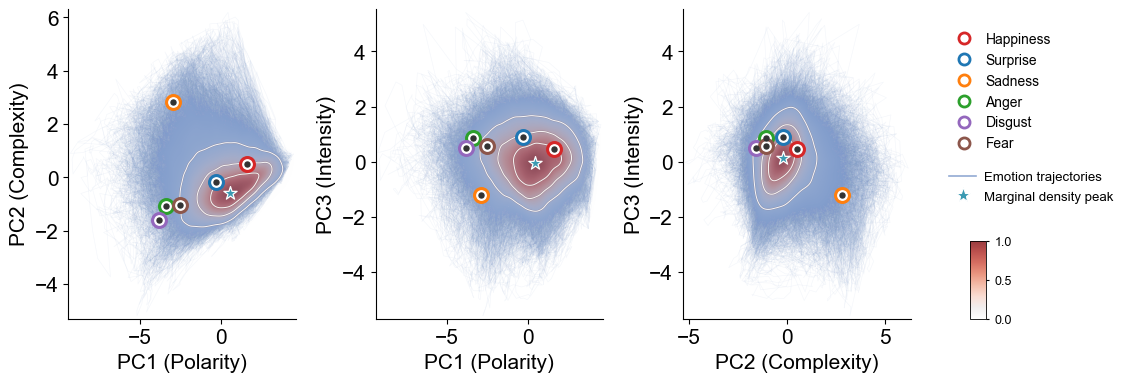

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D


# ============================================================
# 0. Settings
# ============================================================

out_dir = "figures"
os.makedirs(out_dir, exist_ok=True)

out_name = "Supp_emotion_space_3D_marginals_CDE"

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 15


EMO_COLORS = [
    '#d62728',
    '#1f77b4',
    '#ff7f0e',
    '#2ca02c',
    '#9467bd',
    '#8c564b'
]


# ============================================================
# 1. Marginalize the 3D KDE
#
# density.shape = (nx, ny, nz)
#
# Important:
# multiply by the spacing of the integrated-out dimension.
# ============================================================

# PC1-PC2:
# integrate over PC3
dens_12 = (
    density.sum(axis=2)
    * sz
)

# PC1-PC3:
# integrate over PC2
dens_13 = (
    density.sum(axis=1)
    * sy
)

# PC2-PC3:
# integrate over PC1
dens_23 = (
    density.sum(axis=0)
    * sx
)


# ============================================================
# 2. Check probability normalization
# ============================================================

mass_12 = (
    dens_12.sum()
    * sx
    * sy
)

mass_13 = (
    dens_13.sum()
    * sx
    * sz
)

mass_23 = (
    dens_23.sum()
    * sy
    * sz
)


print(
    "Integrated PC1-PC2 marginal:",
    mass_12
)

print(
    "Integrated PC1-PC3 marginal:",
    mass_13
)

print(
    "Integrated PC2-PC3 marginal:",
    mass_23
)


# These should all be approximately 1
assert np.isclose(
    mass_12,
    1.0,
    atol=1e-3
)

assert np.isclose(
    mass_13,
    1.0,
    atol=1e-3
)

assert np.isclose(
    mass_23,
    1.0,
    atol=1e-3
)


# ============================================================
# 3. General 2D HDR threshold function
# ============================================================

def hdr_thresholds_2d(
    dens2d,
    cell_area,
    levels=(0.25, 0.50, 0.75)
):
    """
    Calculate highest-density-region thresholds for
    a 2D probability density.

    Parameters
    ----------
    dens2d : array
        2D probability density.

    cell_area : float
        Physical area represented by each grid cell.

    levels : iterable
        Desired probability masses.

    Returns
    -------
    dict
        {HDR mass: density threshold}
    """

    f = np.asarray(
        dens2d,
        dtype=float
    ).ravel()

    order = np.argsort(
        f
    )[::-1]

    f_sorted = f[
        order
    ]

    cumulative_mass = (
        np.cumsum(f_sorted)
        * cell_area
    )

    total_mass = (
        cumulative_mass[-1]
    )

    thresholds = {}

    for level in levels:

        target = (
            level
            * total_mass
        )

        k = np.searchsorted(
            cumulative_mass,
            target
        )

        k = np.clip(
            k,
            0,
            len(f_sorted) - 1
        )

        thresholds[level] = (
            f_sorted[k]
        )

    return thresholds


# ============================================================
# 4. HDR thresholds for each marginal
# ============================================================

hdr_levels_2d = (
    0.25,
    0.50,
    0.75
)


thr_12 = hdr_thresholds_2d(
    dens_12,
    cell_area=sx * sy,
    levels=hdr_levels_2d
)

thr_13 = hdr_thresholds_2d(
    dens_13,
    cell_area=sx * sz,
    levels=hdr_levels_2d
)

thr_23 = hdr_thresholds_2d(
    dens_23,
    cell_area=sy * sz,
    levels=hdr_levels_2d
)


print(
    "\nPC1-PC2 HDR thresholds:",
    thr_12
)

print(
    "PC1-PC3 HDR thresholds:",
    thr_13
)

print(
    "PC2-PC3 HDR thresholds:",
    thr_23
)


# ============================================================
# 5. Find marginal-density peaks
#
# Mainly diagnostic.
# I do NOT recommend marking them in c-e by default.
# ============================================================

i12 = np.unravel_index(
    np.argmax(dens_12),
    dens_12.shape
)

peak_12 = (
    x_centers[i12[0]],
    y_centers[i12[1]]
)


i13 = np.unravel_index(
    np.argmax(dens_13),
    dens_13.shape
)

peak_13 = (
    x_centers[i13[0]],
    z_centers[i13[1]]
)


i23 = np.unravel_index(
    np.argmax(dens_23),
    dens_23.shape
)

peak_23 = (
    y_centers[i23[0]],
    z_centers[i23[1]]
)


print(
    "\nPC1-PC2 marginal peak:",
    peak_12
)

print(
    "PC1-PC3 marginal peak:",
    peak_13
)

print(
    "PC2-PC3 marginal peak:",
    peak_23
)


# ============================================================
# 6. Normalize marginal densities for DISPLAY
#
# Each marginal density is normalized by its own maximum.
# Therefore the displayed density ranges from 0 to 1.
# ============================================================

dens_12_display = dens_12 / dens_12.max()
dens_13_display = dens_13 / dens_13.max()
dens_23_display = dens_23 / dens_23.max()


# ============================================================
# 7. Density colormap
# ============================================================

density_colors = [
    "white",
    "#F1EEEE",
    "#F9DDD3",
    "#F4BDAA",
    "#EA9680",
    "#D66F62",
    "#BC514E",
    "#983B3F"
]

density_cmap = LinearSegmentedColormap.from_list(
    "soft_density_red",
    density_colors
)


# ============================================================
# 8. Plotting colors / parameters
# ============================================================

TRAJ_COLOR = "#6F8FC5"

traj_alpha = 0.075
traj_lw = 0.45

peak_color = "#3B9AB2"


# ============================================================
# 9. Project emotion centers onto each plane
# ============================================================

C12 = C3[:, [0, 1]]
C13 = C3[:, [0, 2]]
C23 = C3[:, [1, 2]]


# ============================================================
# 10. Helper for one marginal-density panel
# ============================================================

def plot_marginal_density(
    ax,
    xcoords,
    ycoords,
    density_raw,
    density_norm,
    hdr_thresholds,
    center_xy,
    peak_xy,
    trajectory_dims,
    xlabel,
    ylabel,
):
    """
    Plot one pairwise marginal density.

    Parameters
    ----------
    density_raw
        Original marginal probability density.
        Used for HDR contours.

    density_norm
        Marginal density normalized to its own maximum (0--1).
        Used for color visualization.

    peak_xy
        Peak location of this marginal density.

    trajectory_dims
        Tuple giving which PCA dimensions to project:
            (0, 1) -> PC1-PC2
            (0, 2) -> PC1-PC3
            (1, 2) -> PC2-PC3
    """

    ax.set_facecolor("white")


    # ========================================================
    # A. Image extent
    # ========================================================

    dx_local = xcoords[1] - xcoords[0]
    dy_local = ycoords[1] - ycoords[0]

    extent = (
        xcoords[0] - dx_local / 2,
        xcoords[-1] + dx_local / 2,
        ycoords[0] - dy_local / 2,
        ycoords[-1] + dy_local / 2
    )


    # ========================================================
    # B. Projected movie trajectories
    #
    # Draw FIRST, so density is overlaid on trajectories.
    # ========================================================

    dim_x, dim_y = trajectory_dims

    for seg in traj_lines:

        ax.plot(
            seg[:, dim_x],
            seg[:, dim_y],

            color=TRAJ_COLOR,
            lw=traj_lw,
            alpha=traj_alpha,

            zorder=0,
            rasterized=True
        )


    # ========================================================
    # C. Normalized marginal density
    #
    # Spatially varying alpha:
    # - low-density regions remain transparent
    # - high-density core becomes clearly visible
    #
    # This keeps trajectories visible in the periphery.
    # ========================================================

    alpha_map = (
        0.80
        * np.power(
            density_norm.T,
            0.60
        )
    )

    im = ax.imshow(
        density_norm.T,

        extent=extent,
        origin="lower",

        cmap=density_cmap,

        vmin=0,
        vmax=1,

        alpha=alpha_map,

        interpolation="bilinear",
        aspect="auto",

        zorder=1
    )


    # ========================================================
    # D. HDR contours
    # ========================================================

    for level in [
        0.75,
        0.50,
        0.25
    ]:

        cs = ax.contour(
            xcoords,
            ycoords,
            density_raw.T,

            levels=[
                hdr_thresholds[level]
            ],

            colors="white",
            linewidths=0.75,
            alpha=0.90,

            zorder=3
        )

        try:

            for collection in cs.collections:

                collection.set_path_effects([
                    pe.Stroke(
                        linewidth=1.25,
                        foreground="#6F454555"
                    ),
                    pe.Normal()
                ])

        except AttributeError:

            pass


    # ========================================================
    # E. Emotion centers
    # ========================================================

    for k, (cx, cy) in enumerate(
        center_xy
    ):

        ax.scatter(
            [cx],
            [cy],

            s=100,

            facecolors="white",
            edgecolors=EMO_COLORS[k],

            linewidths=2.2,

            zorder=5
        )

        ax.scatter(
            [cx],
            [cy],

            s=13,

            color="#333333",

            zorder=6
        )


    # ========================================================
    # F. Marginal-density peak
    # ========================================================

    ax.scatter(
        [peak_xy[0]],
        [peak_xy[1]],

        marker="*",
        s=100,

        color=peak_color,

        edgecolor="white",
        linewidth=0.9,

        zorder=8
    )


    # ========================================================
    # G. Axes
    # ========================================================

    ax.set_xlim(
        extent[0],
        extent[1]
    )

    ax.set_ylim(
        extent[2],
        extent[3]
    )

    ax.set_xlabel(
        xlabel
    )

    ax.set_ylabel(
        ylabel
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


    return im


# ============================================================
# 11. Create c-d-e
# ============================================================

fig, axs = plt.subplots(
    1,
    3,

    figsize=(10.8, 3.4),

    facecolor="white",
    constrained_layout=False
)

ax_c, ax_d, ax_e = axs


# ============================================================
# c. PC1-PC2 marginal
# ============================================================

im_c = plot_marginal_density(
    ax_c,

    xcoords=x_centers,
    ycoords=y_centers,

    density_raw=dens_12,
    density_norm=dens_12_display,

    hdr_thresholds=thr_12,

    center_xy=C12,
    peak_xy=peak_12,

    trajectory_dims=(0, 1),

    xlabel="PC1 (Polarity)",
    ylabel="PC2 (Complexity)"
)


# ============================================================
# d. PC1-PC3 marginal
# ============================================================

im_d = plot_marginal_density(
    ax_d,

    xcoords=x_centers,
    ycoords=z_centers,

    density_raw=dens_13,
    density_norm=dens_13_display,

    hdr_thresholds=thr_13,

    center_xy=C13,
    peak_xy=peak_13,

    trajectory_dims=(0, 2),

    xlabel="PC1 (Polarity)",
    ylabel="PC3 (Intensity)"
)


# ============================================================
# e. PC2-PC3 marginal
# ============================================================

im_e = plot_marginal_density(
    ax_e,

    xcoords=y_centers,
    ycoords=z_centers,

    density_raw=dens_23,
    density_norm=dens_23_display,

    hdr_thresholds=thr_23,

    center_xy=C23,
    peak_xy=peak_23,

    trajectory_dims=(1, 2),

    xlabel="PC2 (Complexity)",
    ylabel="PC3 (Intensity)"
)


# ============================================================
# 12. Emotion legend
#
# Move the whole legend upward.
# ============================================================

emotion_handles = [

    Line2D(
        [0],
        [0],

        marker="o",
        linestyle="None",

        markerfacecolor="white",
        markeredgecolor=EMO_COLORS[k],
        markeredgewidth=2.0,

        markersize=8,

        label=EMO_NAMES[k]
    )

    for k in range(
        len(EMO_NAMES)
    )
]


fig.legend(
    handles=emotion_handles,

    loc="upper left",

    bbox_to_anchor=(
        0.875,
        0.93
    ),

    frameon=False,

    fontsize=10,

    labelspacing=0.50,
    handletextpad=0.55
)


# ============================================================
# 13. Separate legend for trajectories and marginal peak
# ============================================================

trajectory_handle = Line2D(
    [0],
    [0],

    color=TRAJ_COLOR,
    lw=1.2,
    alpha=0.75,

    label="Emotion trajectories"
)


peak_handle = Line2D(
    [0],
    [0],

    marker="*",
    linestyle="None",

    markerfacecolor=peak_color,
    markeredgecolor="white",
    markeredgewidth=0.8,

    markersize=11,

    label="Marginal density peak"
)


fig.legend(
    handles=[
        trajectory_handle,
        peak_handle
    ],

    loc="upper left",

    bbox_to_anchor=(
        0.875,
        0.52
    ),

    frameon=False,

    fontsize=9.5,

    labelspacing=0.55,
    handletextpad=0.6
)


# ============================================================
# 14. Shared colorbar
# ============================================================

cbar_ax = fig.add_axes([
    0.905,   # left
    0.05,    # bottom
    0.015,   # width
    0.23    # height
])


cbar = fig.colorbar(
    im_e,
    cax=cbar_ax
)


# cbar.set_label(
#     "Normalized density",
#     fontsize=10
# )

cbar.set_ticks([
    0,
    0.5,
    1
])

cbar.ax.tick_params(
    labelsize=9,
    length=2.5
)

cbar.outline.set_linewidth(
    0.6
)


# ============================================================
# 15. Layout
# ============================================================

fig.subplots_adjust(
    left=0.07,
    right=0.85,
    bottom=0.05,
    top=0.96,
    wspace=0.35
)


# ============================================================
# 16. Save
# ============================================================

plt.savefig(
    os.path.join(
        out_dir,
        f"{out_name}.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        out_dir,
        f"{out_name}.pdf"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        out_dir,
        f"{out_name}.svg"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D


# ============================================================
# 0. Settings
# ============================================================

out_dir = "figures"
os.makedirs(out_dir, exist_ok=True)

out_name = "Supp_emotion_space_PC3_marginals"

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 14


EMO_COLORS = [
    '#d62728',
    '#1f77b4',
    '#ff7f0e',
    '#2ca02c',
    '#9467bd',
    '#8c564b'
]

TRAJ_COLOR = "#6F8FC5"
traj_alpha = 0.075
traj_lw = 0.45

peak_color = "#3B9AB2"
profile_color = "#B0396A"


# ============================================================
# 1. Marginalize 3D KDE
# ============================================================

# PC1-PC3: integrate over PC2
dens_13 = density.sum(axis=1) * sy

# PC2-PC3: integrate over PC1
dens_23 = density.sum(axis=0) * sx


# ============================================================
# 2. Normalize for display
# ============================================================

dens_13_norm = dens_13 / dens_13.max()
dens_23_norm = dens_23 / dens_23.max()


# ============================================================
# 3. Find marginal-density peaks
# ============================================================

i13 = np.unravel_index(
    np.argmax(dens_13),
    dens_13.shape
)

peak_13 = (
    x_centers[i13[0]],
    z_centers[i13[1]]
)


i23 = np.unravel_index(
    np.argmax(dens_23),
    dens_23.shape
)

peak_23 = (
    y_centers[i23[0]],
    z_centers[i23[1]]
)


print("PC1-PC3 marginal peak:", peak_13)
print("PC2-PC3 marginal peak:", peak_23)


# ============================================================
# 4. HDR thresholds
# ============================================================

def hdr_thresholds_2d(
    dens2d,
    cell_area,
    levels=(0.25, 0.50, 0.75)
):

    f = np.asarray(
        dens2d,
        float
    ).ravel()

    order = np.argsort(f)[::-1]

    f_sorted = f[order]

    cumulative_mass = (
        np.cumsum(f_sorted)
        * cell_area
    )

    total_mass = cumulative_mass[-1]

    thresholds = {}

    for level in levels:

        k = np.searchsorted(
            cumulative_mass,
            level * total_mass
        )

        k = np.clip(
            k,
            0,
            len(f_sorted) - 1
        )

        thresholds[level] = f_sorted[k]

    return thresholds


thr_13 = hdr_thresholds_2d(
    dens_13,
    cell_area=sx * sz
)

thr_23 = hdr_thresholds_2d(
    dens_23,
    cell_area=sy * sz
)


# ============================================================
# 5. Density colormap
# ============================================================

density_colors = [
    "white",
    "#F1EEEE",
    "#F9DDD3",
    "#F4BDAA",
    "#EA9680",
    "#D66F62",
    "#BC514E",
    "#983B3F"
]

density_cmap = LinearSegmentedColormap.from_list(
    "soft_density_red",
    density_colors
)


# ============================================================
# 6. Emotion centers
# ============================================================

C13 = C3[:, [0, 2]]
C23 = C3[:, [1, 2]]


# ============================================================
# 7. Helper: one joint marginal-density panel
# ============================================================

def plot_joint_marginal(
    fig,
    subplot_spec,
    xcoords,
    ycoords,
    density_raw,
    density_norm,
    hdr_thresholds,
    center_xy,
    peak_xy,
    trajectory_dims,
    xlabel,
    ylabel
):

    # --------------------------------------------------------
    # Nested layout
    #
    #     x-density profile
    #     ----------------
    #     main density      | y-density profile
    #
    # --------------------------------------------------------

    gs = subplot_spec.subgridspec(
        2, 2,
        height_ratios=[0.12, 1.0],
        width_ratios=[1.0, 0.12],
        hspace=0.02,
        wspace=0.02
    )

    ax_top = fig.add_subplot(
        gs[0, 0]
    )

    ax_main = fig.add_subplot(
        gs[1, 0],
        sharex=ax_top
    )

    ax_right = fig.add_subplot(
        gs[1, 1],
        sharey=ax_main
    )

    ax_empty = fig.add_subplot(
        gs[0, 1]
    )
    ax_empty.axis("off")


    # ========================================================
    # A. Grid geometry
    # ========================================================

    dx_local = xcoords[1] - xcoords[0]
    dy_local = ycoords[1] - ycoords[0]

    extent = (
        xcoords[0] - dx_local / 2,
        xcoords[-1] + dx_local / 2,
        ycoords[0] - dy_local / 2,
        ycoords[-1] + dy_local / 2
    )


    # ========================================================
    # B. Exact marginal-peak indices
    # ========================================================

    ix_peak = np.argmin(
        np.abs(
            xcoords - peak_xy[0]
        )
    )

    iy_peak = np.argmin(
        np.abs(
            ycoords - peak_xy[1]
        )
    )


    # ========================================================
    # C. Cross-section density profiles
    #
    # density_norm shape = (nx, ny)
    # ========================================================

    # Vary x, fixing y at marginal-density peak
    density_x = density_norm[
        :,
        iy_peak
    ]

    # Vary y, fixing x at marginal-density peak
    density_y = density_norm[
        ix_peak,
        :
    ]


    # ========================================================
    # D. Projected trajectories
    # ========================================================

    dim_x, dim_y = trajectory_dims

    for seg in traj_lines:

        ax_main.plot(
            seg[:, dim_x],
            seg[:, dim_y],

            color=TRAJ_COLOR,
            lw=traj_lw,
            alpha=traj_alpha,

            rasterized=True,
            zorder=0
        )


    # ========================================================
    # E. Marginal density
    # ========================================================

    alpha_map = (
        0.80
        * density_norm.T ** 0.60
    )

    im = ax_main.imshow(
        density_norm.T,

        extent=extent,
        origin="lower",

        cmap=density_cmap,

        vmin=0,
        vmax=1,

        alpha=alpha_map,

        interpolation="bilinear",
        aspect="auto",

        zorder=1
    )


    # ========================================================
    # F. HDR contours
    # ========================================================

    for level in [
        0.75,
        0.50,
        0.25
    ]:

        cs = ax_main.contour(
            xcoords,
            ycoords,
            density_raw.T,

            levels=[
                hdr_thresholds[level]
            ],

            colors="white",
            linewidths=0.7,
            alpha=0.9,

            zorder=3
        )

        try:

            for collection in cs.collections:

                collection.set_path_effects([
                    pe.Stroke(
                        linewidth=1.2,
                        foreground="#6F454555"
                    ),
                    pe.Normal()
                ])

        except AttributeError:
            pass


    # ========================================================
    # G. Guide lines through marginal-density peak
    # ========================================================

    ax_main.axvline(
        peak_xy[0],
        color=peak_color,
        ls="--",
        lw=0.8,
        alpha=0.55,
        zorder=3.5
    )

    ax_main.axhline(
        peak_xy[1],
        color=peak_color,
        ls="--",
        lw=0.8,
        alpha=0.55,
        zorder=3.5
    )


    # ========================================================
    # H. Emotion centers
    # ========================================================

    for k, (
        cx,
        cy
    ) in enumerate(center_xy):

        ax_main.scatter(
            [cx],
            [cy],

            s=95,

            facecolors="white",
            edgecolors=EMO_COLORS[k],

            linewidths=2.1,

            zorder=5
        )

        ax_main.scatter(
            [cx],
            [cy],

            s=12,

            color="#333333",

            zorder=6
        )


    # ========================================================
    # I. Marginal density peak
    # ========================================================

    ax_main.scatter(
        [peak_xy[0]],
        [peak_xy[1]],

        marker="*",
        s=95,

        color=peak_color,

        edgecolor="white",
        linewidth=0.8,

        zorder=8
    )


    # ========================================================
    # J. Top cross-section
    # ========================================================

    ax_top.plot(
        xcoords,
        density_x,

        color=profile_color,
        lw=1.6
    )

    ax_top.fill_between(
        xcoords,
        0,
        density_x,

        color=profile_color,
        alpha=0.10,
        linewidth=0
    )


    ax_top.axvline(
        peak_xy[0],

        color=peak_color,
        ls="--",
        lw=0.8,
        alpha=0.55
    )


    ax_top.scatter(
        [peak_xy[0]],
        [density_x[ix_peak]],

        s=20,
        color=profile_color,

        edgecolor="white",
        linewidth=0.5,

        zorder=5
    )


    ax_top.set_ylim(
        0,
        1.05
    )

    ax_top.set_yticks(
        [0, 1]
    )

    ax_top.tick_params(
        axis="x",
        bottom=False,
        labelbottom=False
    )

    ax_top.spines["top"].set_visible(False)
    ax_top.spines["right"].set_visible(False)
    ax_top.spines["bottom"].set_visible(False)


    # ========================================================
    # K. Right cross-section
    # ========================================================

    ax_right.plot(
        density_y,
        ycoords,

        color=profile_color,
        lw=1.6
    )

    ax_right.fill_betweenx(
        ycoords,
        0,
        density_y,

        color=profile_color,
        alpha=0.10,
        linewidth=0
    )


    ax_right.axhline(
        peak_xy[1],

        color=peak_color,
        ls="--",
        lw=0.8,
        alpha=0.55
    )


    ax_right.scatter(
        [density_y[iy_peak]],
        [peak_xy[1]],

        s=20,
        color=profile_color,

        edgecolor="white",
        linewidth=0.5,

        zorder=5
    )


    ax_right.set_xlim(
        0,
        1.05
    )

    ax_right.set_xticks(
        [0, 1]
    )

    ax_right.tick_params(
        axis="y",
        left=False,
        labelleft=False
    )

    ax_right.spines["top"].set_visible(False)
    ax_right.spines["right"].set_visible(False)
    ax_right.spines["left"].set_visible(False)


    # ========================================================
    # L. Main axes
    # ========================================================

    ax_main.set_xlim(
        extent[0],
        extent[1]
    )

    ax_main.set_ylim(
        extent[2],
        extent[3]
    )

    ax_main.set_xlabel(
        xlabel
    )

    ax_main.set_ylabel(
        ylabel
    )

    ax_main.spines["top"].set_visible(False)
    ax_main.spines["right"].set_visible(False)


    return (
        ax_main,
        ax_top,
        ax_right,
        im
    )

PC1-PC3 marginal peak: (0.37858832423083566, -0.04764536627389404)
PC2-PC3 marginal peak: (-0.21179995478157876, 0.12099451398755612)


C:\Users\Windows\AppData\Local\Temp\ipykernel_33224\3480775277.py:360: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for collection in cs.collections:


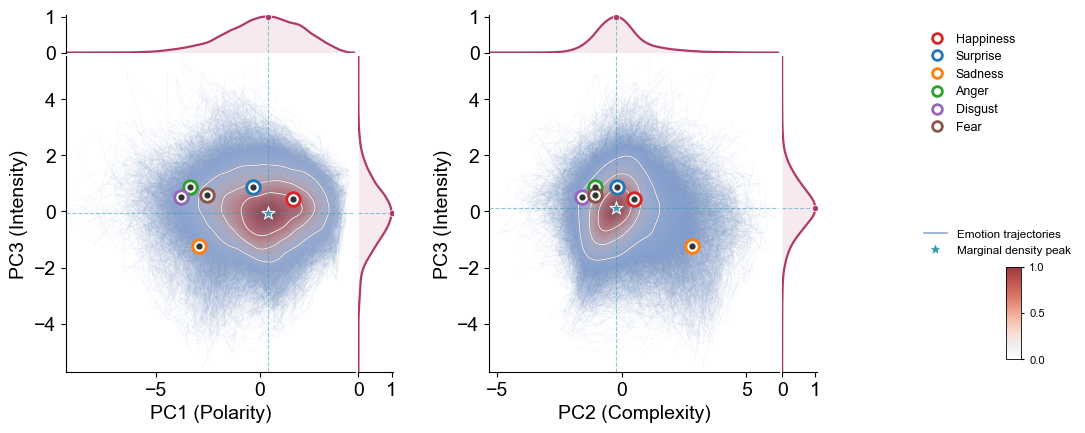

In [16]:
# ============================================================
# 8. Figure: only PC1-PC3 and PC2-PC3
# ============================================================

fig = plt.figure(
    figsize=(11, 4.2),
    facecolor="white"
)


outer = fig.add_gridspec(
    1, 3,

    width_ratios=[
        1.0,
        1.0,
        0.2
    ],

    wspace=0.40
)


# ============================================================
# PC1-PC3
# ============================================================

ax13, ax13_top, ax13_right, im13 = (
    plot_joint_marginal(
        fig,
        outer[0, 0],

        xcoords=x_centers,
        ycoords=z_centers,

        density_raw=dens_13,
        density_norm=dens_13_norm,

        hdr_thresholds=thr_13,

        center_xy=C13,
        peak_xy=peak_13,

        trajectory_dims=(0, 2),

        xlabel="PC1 (Polarity)",
        ylabel="PC3 (Intensity)"
    )
)


# ============================================================
# PC2-PC3
# ============================================================

ax23, ax23_top, ax23_right, im23 = (
    plot_joint_marginal(
        fig,
        outer[0, 1],

        xcoords=y_centers,
        ycoords=z_centers,

        density_raw=dens_23,
        density_norm=dens_23_norm,

        hdr_thresholds=thr_23,

        center_xy=C23,
        peak_xy=peak_23,

        trajectory_dims=(1, 2),

        xlabel="PC2 (Complexity)",
        ylabel="PC3 (Intensity)"
    )
)

# ============================================================
# 9. Legend / colorbar area
# ============================================================

legend_ax = fig.add_subplot(
    outer[0, 2]
)

legend_ax.axis("off")


# ------------------------------------------------------------
# Emotion legend
# ------------------------------------------------------------

emotion_handles = [

    Line2D(
        [0], [0],

        marker="o",
        linestyle="None",

        markerfacecolor="white",
        markeredgecolor=EMO_COLORS[k],
        markeredgewidth=2.0,

        markersize=7,

        label=EMO_NAMES[k]
    )

    for k in range(
        len(EMO_NAMES)
    )
]


leg1 = legend_ax.legend(
    handles=emotion_handles,

    loc="upper left",

    bbox_to_anchor=(
        0.0,
        0.98
    ),

    frameon=False,

    fontsize=9,

    labelspacing=0.45,
    handletextpad=0.5
)

legend_ax.add_artist(
    leg1
)


# ------------------------------------------------------------
# Trajectory + peak legend
# ------------------------------------------------------------

trajectory_handle = Line2D(
    [0], [0],

    color=TRAJ_COLOR,
    lw=1.2,
    alpha=0.75,

    label="Emotion trajectories"
)


peak_handle = Line2D(
    [0], [0],

    marker="*",
    linestyle="None",

    markerfacecolor=peak_color,
    markeredgecolor="white",

    markersize=10,

    label="Marginal density peak"
)


legend_ax.legend(
    handles=[
        trajectory_handle,
        peak_handle
    ],

    loc="upper left",

    bbox_to_anchor=(
        0.0,
        0.43
    ),

    frameon=False,

    fontsize=8.5,

    labelspacing=0.5
)


# ============================================================
# 10. Shared colorbar
# ============================================================

cbar_ax = fig.add_axes([
    0.925,
    0.15,
    0.014,
    0.22
])

cbar = fig.colorbar(
    im23,
    cax=cbar_ax
)

cbar.set_ticks([
    0,
    0.5,
    1
])

cbar.ax.tick_params(
    labelsize=8,
    length=2
)

cbar.outline.set_linewidth(
    0.6
)


# ============================================================
# 11. Layout / save
# ============================================================

fig.subplots_adjust(
    left=0.07,
    right=0.90,
    bottom=0.12,
    top=0.97
)


plt.savefig(
    os.path.join(
        out_dir,
        "Supp_PC3_pairwise_marginals_with_profiles.svg"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()